In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('tanzania.csv', comment='#')


In [3]:
data['Country'] = 'Kenya'

In [4]:
data['Date']=pd.to_datetime(data['YEAR'] * 1000 + data['DOY'], format = '%Y%j')

In [5]:
data['Month']=data['Date'].dt.month

In [6]:
data = data.replace(-999, np.nan)

In [7]:
duplicates = data.duplicated().sum()
print(f"Total number of duplicates {duplicates}")

Total number of duplicates 0


### Duplicates

There are **0** duplicates in the whole dataset.

In [8]:
data.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Statistics Interpretation

Temperature (T2M) averages around 26.8°C, indicating a consistently warm climate with very low variability (std ~1.3°C). Daily maximum and minimum temperatures (~29.2°C and ~25.0°C) are close to each other, resulting in a small diurnal range (~4°C). This suggests minimal day–night temperature fluctuation, typical of humid tropical environments where cloud cover and moisture limit cooling.

Precipitation (PRECTOTCORR) shows a different pattern compared to a dry climate. While the median rainfall is still relatively low (~0.64 mm), the mean (~3.74 mm) and extreme values (up to ~122 mm) indicate frequent rainfall with occasional very intense events. This points to a wetter climate with both regular rain and sporadic heavy downpours.

Humidity (RH2M ~77%) and specific humidity (QV2M ~16.9 g/kg) indicate consistently high atmospheric moisture. The relatively low standard deviation suggests that humidity remains persistently elevated throughout the year, rather than fluctuating dramatically.

Wind speeds are light to moderate (WS2M ~4.1 m/s), with maximum speeds not significantly higher, indicating steady wind conditions without extreme variability. Surface pressure (~100.8 kPa) is also very stable, showing minimal variation over time.

Overall, the dataset reflects a humid tropical climate characterized by consistently warm temperatures, high moisture levels, frequent rainfall, and low diurnal temperature variation. Unlike drier climates, both temperature and humidity remain relatively stable, while rainfall variability is driven by intermittent but sometimes intense precipitation events.


In [9]:
data.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Null Values

There are 0 null values.


In [10]:
columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [11]:
z_scores = (data[columns] - data[columns].mean()) / data[columns].std()

In [12]:
outliers = (np.abs(z_scores) > 3).any(axis=1)

outlier_count = outliers.sum()
print(f"Total number of outlier rows: {outlier_count}")

Total number of outlier rows: 97


In [13]:
data[columns] = data[columns].clip(
    lower=data[columns].quantile(0.01),
    upper=data[columns].quantile(0.99),
    axis=1
)

### Outlier Detection and Basic Cleaning

Since this is a weather dataset, natural spikes are expected. That's why I have decided to cap the outliers 

instead of deleting them. They were identified using a z-score of greater than 3. They are capped using 1st anf 

99th percentile. This preserved important extreme weather events while reducing the influence of noisy values.

In [14]:
data.to_csv('data/tanzania_clean.csv', index = False)

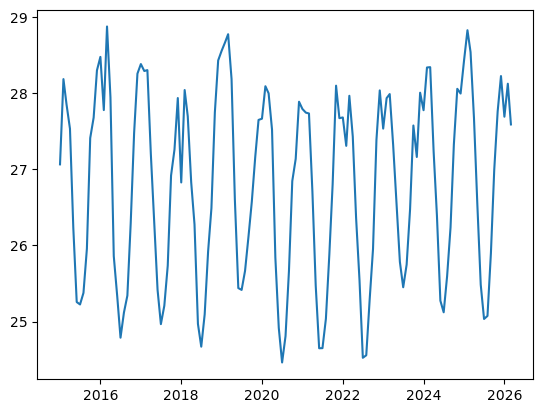

In [15]:
monthly_temp = data.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["Date"], monthly_temp["T2M"])

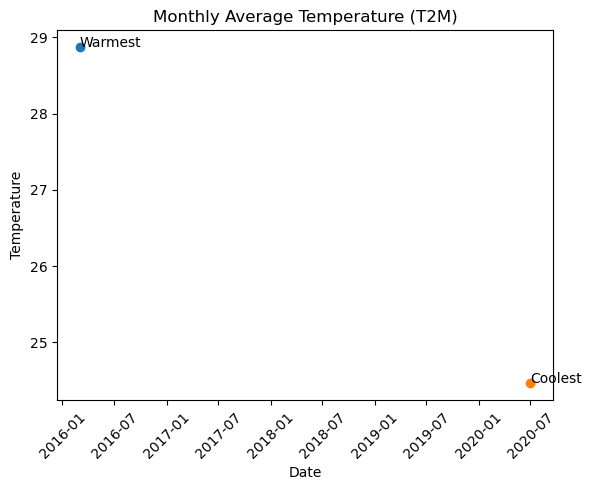

In [16]:
max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.scatter(max_row["Date"], max_row["T2M"])
plt.scatter(min_row["Date"], min_row["T2M"])

plt.text(max_row["Date"], max_row["T2M"], "Warmest")
plt.text(min_row["Date"], min_row["T2M"], "Coolest")

plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

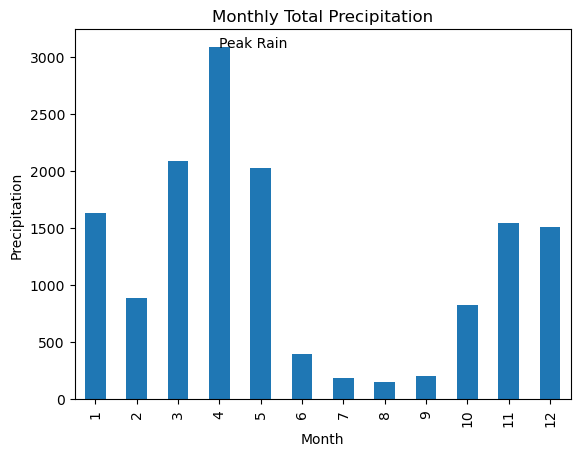

In [17]:
monthly_rain = data.groupby('Month')['PRECTOTCORR'].sum()

plt.figure()
monthly_rain.plot(kind="bar")

# Highlight peak
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.text(peak_month-1, peak_value, "Peak Rain")

plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Analysis

Temperature varies seasonally with clear warm and cool periods. The peak rainfall is recorded on April. As for 

the temperature, the coolest is recorded on the seventh month of 2020 and the warmest on the first month of 2016.

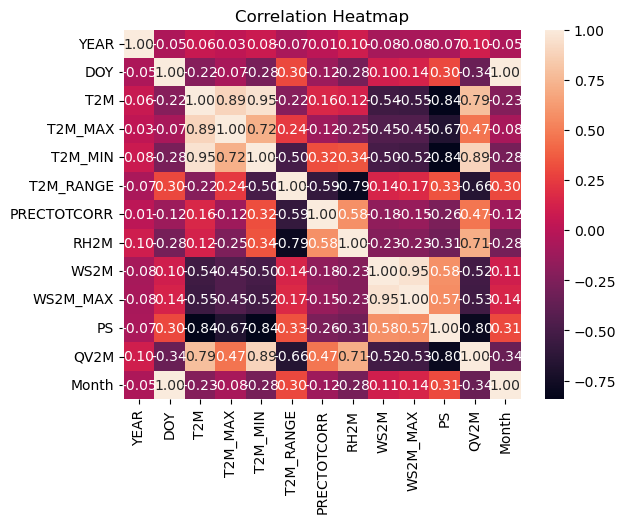

In [18]:
plt.figure()
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

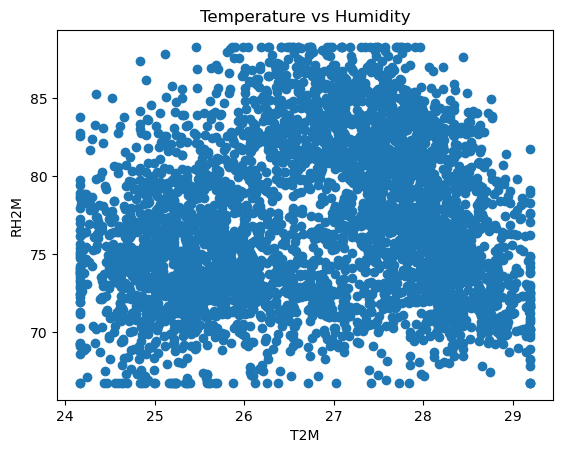

In [19]:
plt.figure()
plt.scatter(data["T2M"], data["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity")
plt.show()

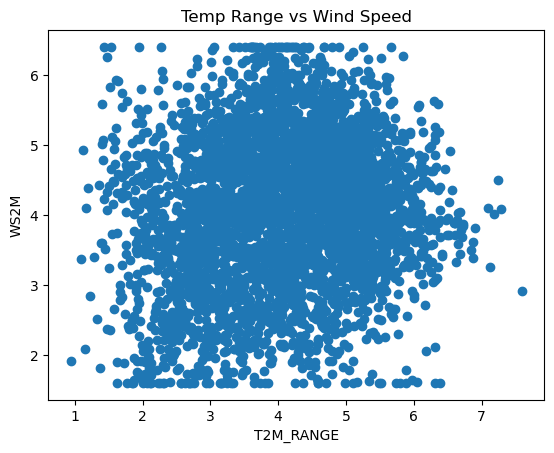

In [20]:
plt.figure()
plt.scatter(data["T2M_RANGE"], data["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temp Range vs Wind Speed")
plt.show()

In [21]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  

print(corr_pairs.head(7))

DOY       Month       0.996557
Month     DOY         0.996557
WS2M_MAX  WS2M        0.951705
WS2M      WS2M_MAX    0.951705
T2M       T2M_MIN     0.950670
T2M_MIN   T2M         0.950670
T2M_MAX   T2M         0.889115
dtype: float64


### Correlation Interpretation

The strongest correlations in the dataset highlight both redundancy in features and meaningful physical relationships, while still aligning with the broader seasonal structure.

DOY and Month show an almost perfect correlation (~0.997), confirming that they represent the same annual cycle and are effectively interchangeable as time indicators.

Wind-related variables exhibit an even stronger relationship than before, with WS2M and WS2M_MAX (~0.95) very tightly coupled. This suggests that average and peak wind speeds move almost in lockstep, indicating highly consistent wind behavior with minimal unexpected spikes.

A key shift in this dataset is the very strong relationship between T2M and T2M_MIN (~0.95). This indicates that average temperature is heavily influenced by nighttime temperatures, suggesting limited temperature variation within a day. In other words, when nights are warmer, the overall daily temperature rises accordingly, pointing to a thermally stable environment.

Temperature variables remain strongly connected overall, with T2M and T2M_MAX (~0.89) also showing a high correlation. This confirms that daily temperature patterns are consistent, with maximum temperatures scaling predictably with the overall average.

Unlike earlier observations, moisture variables are no longer among the strongest correlations. Instead, temperature relationships dominate, particularly the strong link between average and minimum temperatures. This suggests that thermal consistency, rather than moisture variability, is the more defining characteristic of this dataset.

Seasonally, these relationships still align with the annual cycle captured by DOY and Month, but the high correlations among temperature variables indicate that temperature changes are smooth and uniform across time, rather than sharply fluctuating.

Overall, the dataset shows expected redundancy in time variables and very strong internal consistency within wind and temperature measurements. The dominance of temperature correlations, especially between average and minimum values, highlights a climate with low diurnal variability and stable thermal conditions throughout the year.

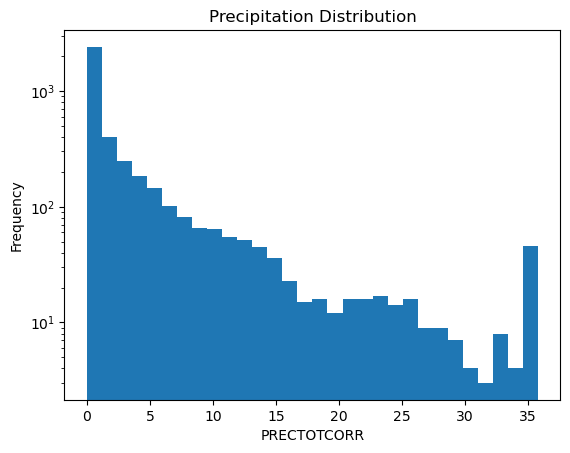

In [22]:
plt.figure()
plt.hist(data["PRECTOTCORR"], bins=30)

plt.yscale("log")  # helps if skewed

plt.title("Precipitation Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

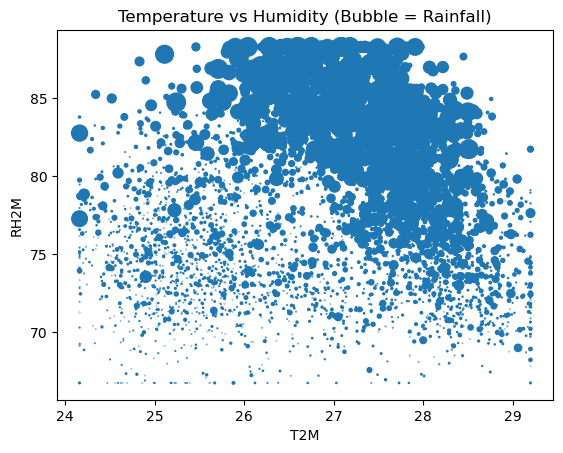

In [23]:
plt.figure()
plt.scatter(
    data["T2M"],
    data["RH2M"],
    s=data["PRECTOTCORR"] * 5  
)

plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()